# DELPHIN — Semana 3: Procesamiento de Texto y Embeddings BERT (DAIC-WOZ)

**Objetivo de la semana:** extraer representaciones vectoriales del texto (transcripciones) del corpus DAIC-WOZ mediante BERT y dejar preparados los artefactos (`embeddings.csv`, `texto_dataset.csv`, `X_text.npy`, `y_text.npy`, `split_text.npy`, scaler y métricas) que consumirán las Semanas 4 y 5, en un formato totalmente compatible con los productos de la Semana 2.

**Corrección metodológica crítica aplicada respecto a la versión anterior de este notebook:**
- La versión anterior usaba `dev_split_Depression_AVEC2017.csv` (35 participantes) como conjunto de **entrenamiento** y `full_test_split.csv` como conjunto de **prueba**, dejando sin usar el `train_split_Depression_AVEC2017.csv` oficial (107 participantes). Esto contradice la metodología oficial de DAIC-WOZ/AVEC2017, usada correctamente en la Semana 2, y hace que los conjuntos de la Semana 3 sean **incompatibles** con los de la Semana 2 (distintos participantes, distinto tamaño, distinto significado del nombre `split`).
- **Corrección:** al igual que en la Semana 2, **Entrenamiento → únicamente TRAIN** (`train_split_Depression_AVEC2017.csv`, 107 participantes). **Validación → únicamente DEV** (`dev_split_Depression_AVEC2017.csv`, 35 participantes). El TEST oficial (sin etiquetas) y el FULL_TEST (reservado para una evaluación final independiente) **no** se usan para entrenar, validar, ni para ninguna etapa de limpieza, tokenización o extracción de embeddings.
- Se genera únicamente texto/embeddings para los participantes de TRAIN y DEV (nunca para TEST/FULL_TEST), y se conserva una columna `split` (`train` / `dev`) en `texto_dataset.csv`, exactamente con la misma semántica que en `audio_dataset.csv` de la Semana 2, para permitir la integración multimodal en la Semana 5 sin reprocesar nada.


## 1. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Rutas del proyecto y librerías

In [ ]:
import os
import re
import json as _json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import joblib

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Carpeta con los datos crudos del corpus DAIC-WOZ (transcripciones + splits oficiales)
# Debe ser exactamente la misma ruta usada en la Semana 2.
BASE = "/content/drive/MyDrive/DAIC-WOZ"

# Carpeta donde se guardan los productos del proyecto DELPHIN (consumidos por Semanas 4-5)
# Debe ser exactamente la misma ruta usada en la Semana 2, para que ambas semanas
# lean y escriban en el mismo lugar.
BASE_PROYECTO = Path("/content/drive/MyDrive/Colab Notebooks/Programa Delphin")
BASE_PROYECTO.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Existe BASE:", os.path.exists(BASE))
print("Productos se guardarán en:", BASE_PROYECTO)
print("Device:", device)

Existe BASE: True
Productos se guardarán en: /content/drive/MyDrive/Colab Notebooks/Programa Delphin
Device: cpu


## 3. Carga de los splits oficiales y validación de la metodología

Se cargan los cuatro archivos oficiales del protocolo AVEC2017/DAIC-WOZ, **exactamente igual que en la Semana 2**. `TEST` no tiene etiquetas de depresión y **nunca** se usa. `FULL_TEST` sí tiene etiquetas pero se reserva únicamente para una evaluación final independiente: **no participa del entrenamiento ni de la validación de la Semana 3**, ni de ninguna etapa de limpieza, tokenización o extracción de embeddings.

In [ ]:
train_df = pd.read_csv(f"{BASE}/train_split_Depression_AVEC2017.csv")
dev_df   = pd.read_csv(f"{BASE}/dev_split_Depression_AVEC2017.csv")
test_df  = pd.read_csv(f"{BASE}/test_split_Depression_AVEC2017.csv")
full_test_df = pd.read_csv(f"{BASE}/full_test_split.csv")

print("TRAIN:", train_df.shape, "columnas:", train_df.columns.tolist())
print("DEV  :", dev_df.shape, "columnas:", dev_df.columns.tolist())
print("TEST (sin etiquetas):", test_df.shape, "columnas:", test_df.columns.tolist())
print("FULL_TEST (reservado, no se usa en Semana 3):", full_test_df.shape, "columnas:", full_test_df.columns.tolist())

# Homologar nombres de columnas de etiqueta en full_test (por si se usa en una evaluación final futura)
full_test_df = full_test_df.rename(columns={"PHQ_Binary": "PHQ8_Binary", "PHQ_Score": "PHQ8_Score"})

# Verificación de que no hay solapamiento de participantes entre TRAIN y DEV
solapamiento = set(train_df["Participant_ID"]) & set(dev_df["Participant_ID"])
assert len(solapamiento) == 0, f"TRAIN y DEV comparten participantes: {solapamiento}"
print("\nOK: TRAIN y DEV no comparten participantes.")

TRAIN: (107, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
DEV  : (35, 12) columnas: ['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired', 'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']
TEST (sin etiquetas): (47, 2) columnas: ['participant_ID', 'Gender']
FULL_TEST (reservado, no se usa en Semana 3): (47, 4) columnas: ['Participant_ID', 'PHQ_Binary', 'PHQ_Score', 'Gender']

OK: TRAIN y DEV no comparten participantes.


## 4. Verificación de compatibilidad con la Semana 2

Antes de procesar nada, se comprueba que los participantes de TRAIN/DEV usados aquí coinciden exactamente con los usados en `audio_dataset.csv` de la Semana 2. Esto garantiza que la fusión multimodal de la Semana 5 podrá alinear audio y texto participante por participante.

In [ ]:
audio_dataset_ref = pd.read_csv(BASE_PROYECTO / "audio_dataset.csv")

ids_audio_train = set(audio_dataset_ref.loc[audio_dataset_ref["split"] == "train", "Participant_ID"])
ids_audio_dev   = set(audio_dataset_ref.loc[audio_dataset_ref["split"] == "dev", "Participant_ID"])

ids_text_train = set(train_df["Participant_ID"])
ids_text_dev   = set(dev_df["Participant_ID"])

assert ids_audio_train == ids_text_train, (
    "Los participantes de TRAIN de texto no coinciden con los de audio (Semana 2). "
    "La integración multimodal de la Semana 5 requiere participantes idénticos."
)
assert ids_audio_dev == ids_text_dev, (
    "Los participantes de DEV de texto no coinciden con los de audio (Semana 2)."
)

print("OK: los conjuntos TRAIN y DEV de texto coinciden exactamente con los de audio (Semana 2).")
print(f"TRAIN: {len(ids_text_train)} participantes | DEV: {len(ids_text_dev)} participantes")

OK: los conjuntos TRAIN y DEV de texto coinciden exactamente con los de audio (Semana 2).
TRAIN: 107 participantes | DEV: 35 participantes


## 5. Carga y filtrado de transcripciones

Solo se conservan las intervenciones donde `speaker == "Participant"`. Incluir las preguntas de la entrevistadora (Ellie) produce data leakage severo, ya que el protocolo de entrevista de Ellie está correlacionado con la puntuación PHQ-8 (Burdisso et al., 2024).

In [ ]:
from pathlib import Path
import pandas as pd

def load_transcript(pid, data_dir):
    """
    Carga el archivo TRANSCRIPT.csv de un participante y conserva únicamente
    las intervenciones del participante (no las del entrevistador).
    Compatible con la estructura del dataset utilizada en este proyecto.
    """

    data_dir = Path(data_dir)
    path = data_dir / f"{pid}_TRANSCRIPT.csv"

    if not path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {path}")

    df = pd.read_csv(path, sep="\t")

    # Mantener únicamente las intervenciones del participante
    df = df[df["speaker"] == "Participant"]

    # Eliminar filas sin texto
    df = df.dropna(subset=["value"])

    # Convertir a texto
    df["value"] = df["value"].astype(str)

    return df


def get_full_text(pid, data_dir):
    """
    Concatena todas las intervenciones del participante en un único texto.
    """

    df = load_transcript(pid, data_dir)

    return " ".join(df["value"]).strip()


# ============================================================
# Prueba de funcionamiento
# ============================================================

texto_demo = get_full_text(300, BASE)

print("Participante:", 300)
print("Palabras:", len(texto_demo.split()))
print("\nPrimeros 500 caracteres:\n")
print(texto_demo[:500])

Participante: 300
Palabras: 352

Primeros 500 caracteres:

good atlanta georgia um my parents are from here um i love it i like the weather i like the opportunities um yes um it took a minute somewhat easy congestion that's it um i took up business and administration uh yeah i am here and there i'm on a break right now but i plan on going back in the uh next semester uh probably to open up my own business no um no specific reason i just don't travel a lot i'm pretty local once a year can you be a little bit more specific no answer i like reading books i


## 6. Limpieza del texto

**Nota metodológica:** se decidió **conservar** las disfluencias del habla (*um*, *uh*, *hmm*, etc.) en lugar de eliminarlas, porque la literatura las reporta como posible indicador del estado cognitivo/emocional del hablante y BERT puede beneficiarse de esa señal adicional. Esta decisión, ya presente y justificada en la versión anterior del notebook, se conserva sin cambios porque es una decisión de diseño válida y no un error metodológico. La limpieza se limita a normalizar espacios en blanco; la conversión a minúsculas es redundante con `bert-base-uncased` (el propio tokenizer normaliza a minúsculas) pero se mantiene explícita para que el conteo de tokens y el texto mostrado en las celdas de inspección sean consistentes con lo que ve el modelo.

In [ ]:
def clean_text(text):
    """Limpieza mínima y justificada: minúsculas + normalización de espacios.
    No se eliminan disfluencias (um, uh, hmm) de forma deliberada (ver nota arriba)."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


texto_demo_limpio = clean_text(texto_demo)
print(texto_demo_limpio[:300])

good atlanta georgia um my parents are from here um i love it i like the weather i like the opportunities um yes um it took a minute somewhat easy congestion that's it um i took up business and administration uh yeah i am here and there i'm on a break right now but i plan on going back in the uh nex


## 7. Carga del tokenizer y del modelo BERT (congelado)

Se usa `bert-base-uncased` en modo *feature extraction*: el modelo se congela (`model.eval()` + `torch.no_grad()`), no se ajustan sus pesos. `max_length=512` es el máximo soportado por BERT base; `padding="max_length"` y `truncation=True` garantizan tensores de tamaño fijo para todos los participantes; `attention_mask` se pasa siempre para que el modelo ignore el padding.

In [ ]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval().to(device)

print("Modelo cargado:", MODEL_NAME)
print("Device:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: bert-base-uncased
Device: cpu


## 8. Inspección de la tokenización (participante 300)

In [ ]:
enc_demo = tokenizer(
    texto_demo_limpio,
    max_length=512,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

print("input_ids shape     :", enc_demo["input_ids"].shape)
print("attention_mask shape:", enc_demo["attention_mask"].shape)

tokens_demo = tokenizer.convert_ids_to_tokens(enc_demo["input_ids"][0][:12].tolist())
print("\nPrimeros 12 tokens:", tokens_demo)

input_ids shape     : torch.Size([1, 512])
attention_mask shape: torch.Size([1, 512])

Primeros 12 tokens: ['[CLS]', 'good', 'atlanta', 'georgia', 'um', 'my', 'parents', 'are', 'from', 'here', 'um', 'i']


## 9. Función `extract_text_features`

Análoga a `extract_features(wav_path)` de la Semana 2: recibe un `Participant_ID` y devuelve un vector de 768 dimensiones (embedding `[CLS]` de la última capa de BERT). El modelo permanece congelado (`torch.no_grad()`), y se valida explícitamente que el vector resultante no contenga NaN/Inf.

In [ ]:
def extract_text_features(pid, data_dir, tok, mdl, device):
    """Extrae el embedding [CLS] (768,) de BERT para un participante,
    a partir de sus intervenciones filtradas y limpias."""
    text = get_full_text(pid, data_dir)
    text = clean_text(text)

    enc = tok(
        text,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        out = mdl(**enc)

    cls = out.last_hidden_state[:, 0, :]
    feats = cls.cpu().numpy().squeeze().astype(np.float32)

    assert not np.any(np.isnan(feats)), f"Embedding con NaN para participante {pid}"
    assert not np.any(np.isinf(feats)), f"Embedding con Inf para participante {pid}"

    return feats


def text_feature_names():
    return [f"emb_{i}" for i in range(768)]


# Prueba con el participante 300
feats_demo = extract_text_features(300, BASE, tokenizer, bert_model, device)
print("Longitud del vector de características:", feats_demo.shape)
assert feats_demo.shape[0] == 768, "El embedding debe tener 768 dimensiones"
print("OK: embedding de 768 dimensiones, sin NaN ni Inf.")

Longitud del vector de características: (768,)
OK: embedding de 768 dimensiones, sin NaN ni Inf.


## 10. Procesar TRAIN y DEV (los únicos splits usados en la Semana 3)

Función reutilizable, análoga a `process_split` de la Semana 2: recorre los `Participant_ID` de un split, extrae el embedding para cada transcripción disponible y **reporta explícitamente** los participantes cuya transcripción no se encontró (en vez de omitirlos silenciosamente). **No se procesa ningún participante de TEST ni de FULL_TEST.**

In [ ]:
from pathlib import Path

def process_split_text(participant_ids, data_dir, split_name, tok, mdl, device):
    """
    Procesa un conjunto (TRAIN o DEV), genera los embeddings BERT
    y construye el DataFrame de características.
    Compatible con la estructura del DAIC-WOZ utilizada en este proyecto.
    """

    filas = []
    faltantes = []

    data_dir = Path(data_dir)

    for pid in participant_ids:

        transcript_path = data_dir / f"{pid}_TRANSCRIPT.csv"

        if not transcript_path.exists():
            faltantes.append(pid)
            continue

        feats = extract_text_features(pid, data_dir, tok, mdl, device)

        filas.append([pid] + feats.tolist())

    columnas = ["Participant_ID"] + text_feature_names()

    df_feats = pd.DataFrame(filas, columns=columnas)

    df_feats["split"] = split_name

    print(
        f"[{split_name}] participantes solicitados: {len(participant_ids)} | "
        f"procesados: {len(df_feats)} | "
        f"sin transcripción: {len(faltantes)}"
    )

    if len(faltantes) > 0:
        print(f"[{split_name}] IDs sin transcripción:")
        print(faltantes)

    return df_feats


# ============================================================
# Procesamiento TRAIN + DEV
# ============================================================

texto_train_feats = process_split_text(
    train_df["Participant_ID"],
    BASE,
    "train",
    tokenizer,
    bert_model,
    device,
)

texto_dev_feats = process_split_text(
    dev_df["Participant_ID"],
    BASE,
    "dev",
    tokenizer,
    bert_model,
    device,
)

texto_features_df = pd.concat(
    [texto_train_feats, texto_dev_feats],
    ignore_index=True
)

print("\ntexto_features_df:", texto_features_df.shape)

display(texto_features_df.head())

[train] participantes solicitados: 107 | procesados: 107 | sin transcripción: 0
[dev] participantes solicitados: 35 | procesados: 35 | sin transcripción: 0

texto_features_df: (142, 770)


,Participant_ID,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,split
0,303,-0.102620,0.263089,0.237846,0.204002,-0.170751,-0.105257,0.155405,0.874446,-0.230149,...,-0.955053,-0.093463,-0.298892,0.362784,0.523140,-0.216216,-0.460964,-0.135334,-0.252775,train
1,304,0.031289,-0.076062,0.399899,0.101374,-0.302885,0.020719,0.390248,0.673135,-0.016671,...,-0.711380,-0.115885,0.019373,0.149931,0.414613,-0.346800,-0.336720,0.274709,-0.392734,train
2,305,-0.350703,0.203322,0.233890,-0.166671,-0.347913,0.035391,0.461639,0.834861,-0.197926,...,-1.044441,-0.371975,-0.091724,0.381081,0.432922,-0.102070,-0.286150,0.506875,-0.428177,train
3,310,-0.250767,0.156797,0.560445,-0.250063,-0.543560,-0.430293,0.281607,0.841378,0.007012,...,-0.731807,-0.065518,-0.080725,0.289283,0.602622,-0.527158,-0.352471,0.033194,-0.204459,train
4,312,-0.060397,0.294033,0.361038,0.193692,-0.545300,-0.396156,0.337546,0.750001,-0.121103,...,-0.766447,-0.203802,0.052177,0.337609,0.667181,-0.170267,-0.363869,0.294683,-0.077554,train


## 11. Construir y guardar `embeddings.csv`

Contiene únicamente TRAIN + DEV, con la columna `split`, exactamente en el mismo espíritu que `audio_features.csv` de la Semana 2.

In [ ]:
texto_features_df.to_csv(BASE_PROYECTO / "embeddings.csv", index=False)
print("✓ embeddings.csv guardado:", texto_features_df.shape)

✓ embeddings.csv guardado: (142, 770)


## 12. Construir `texto_dataset.csv` (embeddings + etiquetas)

Se agregan las etiquetas `PHQ8_Binary` y `PHQ8_Score` desde `train_split` y `dev_split` respectivamente. El TEST oficial (sin etiquetas) y el FULL_TEST quedan explícitamente excluidos de este merge.

In [ ]:
# ============================================================
# CONSTRUCCIÓN DEL DATASET FINAL DE TEXTO
# ============================================================

# Etiquetas TRAIN + DEV
labels_train = train_df[
    ["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]
].copy()

labels_dev = dev_df[
    ["Participant_ID", "PHQ8_Binary", "PHQ8_Score"]
].copy()

labels_df = pd.concat(
    [labels_train, labels_dev],
    ignore_index=True
)

# Normalizar tipos
texto_features_df["Participant_ID"] = (
    texto_features_df["Participant_ID"]
    .astype(int)
)

labels_df["Participant_ID"] = (
    labels_df["Participant_ID"]
    .astype(int)
)

# Verificación previa
ids_text = set(texto_features_df["Participant_ID"])
ids_labels = set(labels_df["Participant_ID"])

print("=" * 60)
print("VERIFICACIÓN PREVIA AL MERGE")
print("=" * 60)
print("Embeddings :", len(ids_text))
print("Etiquetas  :", len(ids_labels))
print("IDs comunes:", len(ids_text & ids_labels))
print()

assert ids_text == ids_labels, (
    "Los Participant_ID de embeddings y etiquetas no coinciden."
)

# ============================================================
# MERGE
# ============================================================

texto_dataset_df = pd.merge(
    texto_features_df,
    labels_df,
    on="Participant_ID",
    how="inner",
    validate="one_to_one"
)

assert len(texto_dataset_df) == 142, (
    f"Se esperaban 142 participantes y se obtuvieron "
    f"{len(texto_dataset_df)}."
)

# ============================================================
# GUARDAR DATASET
# ============================================================

texto_dataset_df.to_csv(
    BASE_PROYECTO / "texto_dataset.csv",
    index=False
)

print("✓ texto_dataset.csv guardado:", texto_dataset_df.shape)

print("\nDistribución por split:")
print(texto_dataset_df["split"].value_counts())

print("\nDistribución de PHQ8_Binary por split:")
print(
    texto_dataset_df.groupby("split")["PHQ8_Binary"]
    .value_counts()
)

display(texto_dataset_df.head())

VERIFICACIÓN PREVIA AL MERGE
Embeddings : 142
Etiquetas  : 142
IDs comunes: 142

✓ texto_dataset.csv guardado: (142, 772)

Distribución por split:
split
train    107
dev       35
Name: count, dtype: int64

Distribución de PHQ8_Binary por split:
split  PHQ8_Binary
dev    0              23
       1              12
train  0              77
       1              30
Name: count, dtype: int64


,Participant_ID,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,split,PHQ8_Binary,PHQ8_Score
0,303,-0.102620,0.263089,0.237846,0.204002,-0.170751,-0.105257,0.155405,0.874446,-0.230149,...,-0.298892,0.362784,0.523140,-0.216216,-0.460964,-0.135334,-0.252775,train,0,0
1,304,0.031289,-0.076062,0.399899,0.101374,-0.302885,0.020719,0.390248,0.673135,-0.016671,...,0.019373,0.149931,0.414613,-0.346800,-0.336720,0.274709,-0.392734,train,0,6
2,305,-0.350703,0.203322,0.233890,-0.166671,-0.347913,0.035391,0.461639,0.834861,-0.197926,...,-0.091724,0.381081,0.432922,-0.102070,-0.286150,0.506875,-0.428177,train,0,7
3,310,-0.250767,0.156797,0.560445,-0.250063,-0.543560,-0.430293,0.281607,0.841378,0.007012,...,-0.080725,0.289283,0.602622,-0.527158,-0.352471,0.033194,-0.204459,train,0,4
4,312,-0.060397,0.294033,0.361038,0.193692,-0.545300,-0.396156,0.337546,0.750001,-0.121103,...,0.052177,0.337609,0.667181,-0.170267,-0.363869,0.294683,-0.077554,train,0,2


## 13. Verificación: TEST y FULL_TEST no participan del dataset de texto

In [ ]:
print("Shape:", texto_dataset_df.shape)

display(texto_dataset_df.head())

print(texto_dataset_df.columns)

Shape: (142, 772)


,Participant_ID,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,split,PHQ8_Binary,PHQ8_Score
0,303,-0.102620,0.263089,0.237846,0.204002,-0.170751,-0.105257,0.155405,0.874446,-0.230149,...,-0.298892,0.362784,0.523140,-0.216216,-0.460964,-0.135334,-0.252775,train,0,0
1,304,0.031289,-0.076062,0.399899,0.101374,-0.302885,0.020719,0.390248,0.673135,-0.016671,...,0.019373,0.149931,0.414613,-0.346800,-0.336720,0.274709,-0.392734,train,0,6
2,305,-0.350703,0.203322,0.233890,-0.166671,-0.347913,0.035391,0.461639,0.834861,-0.197926,...,-0.091724,0.381081,0.432922,-0.102070,-0.286150,0.506875,-0.428177,train,0,7
3,310,-0.250767,0.156797,0.560445,-0.250063,-0.543560,-0.430293,0.281607,0.841378,0.007012,...,-0.080725,0.289283,0.602622,-0.527158,-0.352471,0.033194,-0.204459,train,0,4
4,312,-0.060397,0.294033,0.361038,0.193692,-0.545300,-0.396156,0.337546,0.750001,-0.121103,...,0.052177,0.337609,0.667181,-0.170267,-0.363869,0.294683,-0.077554,train,0,2


Index(['Participant_ID', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5',
       'emb_6', 'emb_7', 'emb_8',
       ...
       'emb_761', 'emb_762', 'emb_763', 'emb_764', 'emb_765', 'emb_766',
       'emb_767', 'split', 'PHQ8_Binary', 'PHQ8_Score'],
      dtype='object', length=772)


## 14. Construcción de `X`/`y` usando el split oficial

Igual que en la Semana 2: se usa directamente la partición oficial del corpus (TRAIN para entrenar, DEV para validar), sin ningún `train_test_split` aleatorio adicional.

In [ ]:
feature_cols_text = text_feature_names()

train_mask_text = texto_dataset_df["split"] == "train"
dev_mask_text = texto_dataset_df["split"] == "dev"

X_train_text_raw = texto_dataset_df.loc[train_mask_text, feature_cols_text].values
y_train_text = texto_dataset_df.loc[train_mask_text, "PHQ8_Binary"].values.astype(np.float32)

X_dev_text_raw = texto_dataset_df.loc[dev_mask_text, feature_cols_text].values
y_dev_text = texto_dataset_df.loc[dev_mask_text, "PHQ8_Binary"].values.astype(np.float32)

print("X_train:", X_train_text_raw.shape, " y_train:", y_train_text.shape)
print("X_dev  :", X_dev_text_raw.shape, " y_dev  :", y_dev_text.shape)

X_train: (107, 768)  y_train: (107,)
X_dev  : (35, 768)  y_dev  : (35,)


## 15. Escalado de características

`StandardScaler` ajustado **únicamente con TRAIN** y luego aplicado a TRAIN y a DEV, para evitar fuga de información desde el conjunto de validación (igual que en la Semana 2).

In [ ]:
scaler_text = StandardScaler()
X_train_text = scaler_text.fit_transform(X_train_text_raw)
X_dev_text = scaler_text.transform(X_dev_text_raw)

joblib.dump(scaler_text, BASE_PROYECTO / "scaler_text.pkl")
print("✓ Scaler ajustado sobre TRAIN y guardado en scaler_text.pkl")

✓ Scaler ajustado sobre TRAIN y guardado en scaler_text.pkl


## 16. Conversión a tensores de PyTorch

In [ ]:
X_train_text_t = torch.tensor(X_train_text, dtype=torch.float32)
y_train_text_t = torch.tensor(y_train_text, dtype=torch.float32).view(-1, 1)

X_dev_text_t = torch.tensor(X_dev_text, dtype=torch.float32)
y_dev_text_t = torch.tensor(y_dev_text, dtype=torch.float32).view(-1, 1)

print(X_train_text_t.shape, y_train_text_t.shape)
print(X_dev_text_t.shape, y_dev_text_t.shape)

torch.Size([107, 768]) torch.Size([107, 1])
torch.Size([35, 768]) torch.Size([35, 1])


## 17. Dataset y DataLoader (`train_loader_text`, `valid_loader_text`)

In [ ]:
train_dataset_text = TensorDataset(X_train_text_t, y_train_text_t)
valid_dataset_text = TensorDataset(X_dev_text_t, y_dev_text_t)

train_loader_text = DataLoader(train_dataset_text, batch_size=8, shuffle=True)
valid_loader_text = DataLoader(valid_dataset_text, batch_size=8, shuffle=False)

print("Batches de entrenamiento:", len(train_loader_text))
print("Batches de validación   :", len(valid_loader_text))

Batches de entrenamiento: 14
Batches de validación   : 5


## 18. Arquitectura del clasificador de texto

MLP simple sobre el embedding BERT congelado (768 → 256 → 64 → 1), siguiendo la arquitectura sugerida en el material de la Semana 3 y el mismo patrón de la `AudioMLP` de la Semana 2 (Linear + ReLU + Dropout, salida con `Sigmoid` para clasificación binaria).

In [ ]:
class TextMLP(nn.Module):
    def __init__(self, input_dim=768, hidden=256, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(drop),

            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(drop),

            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


input_dim_text = X_train_text_t.shape[1]
text_model = TextMLP(input_dim=input_dim_text)
print(text_model)

x_test_text = torch.randn(4, input_dim_text)
y_hat_text = text_model(x_test_text)
print("Forma de salida de prueba:", y_hat_text.shape)

TextMLP(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Forma de salida de prueba: torch.Size([4, 1])


## 19. Entrenamiento con validación en cada época

Entrena únicamente sobre `train_loader_text` (TRAIN) y valida sobre `valid_loader_text` (DEV) al final de cada época. Se guarda el mejor modelo según F1 de validación (checkpointing).

In [ ]:
criterion_text = nn.BCELoss()
optimizer_text = torch.optim.Adam(text_model.parameters(), lr=1e-3)

N_EPOCHS_TEXT = 30
best_val_f1_text = -1.0
best_state_text = None

history_text = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(N_EPOCHS_TEXT):
    text_model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader_text:
        optimizer_text.zero_grad()
        outputs = text_model(X_batch)
        loss = criterion_text(outputs, y_batch)
        loss.backward()
        optimizer_text.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader_text)

    text_model.eval()
    val_running_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in valid_loader_text:
            outputs = text_model(X_batch)
            loss = criterion_text(outputs, y_batch)
            val_running_loss += loss.item()

            preds = (outputs > 0.5).float()
            all_preds.append(preds)
            all_targets.append(y_batch)

    val_loss = val_running_loss / len(valid_loader_text)
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)

    history_text["train_loss"].append(train_loss)
    history_text["val_loss"].append(val_loss)
    history_text["val_acc"].append(val_acc)
    history_text["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_text:
        best_val_f1_text = val_f1
        best_state_text = {k: v.clone() for k, v in text_model.state_dict().items()}

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

if best_state_text is not None:
    text_model.load_state_dict(best_state_text)
    print(f"\nMejor F1 de validación: {best_val_f1_text:.4f} (modelo restaurado)")

Epoch 01 | train_loss=0.6561 | val_loss=0.6464 | val_acc=0.6571 | val_f1=0.0000
Epoch 02 | train_loss=0.4460 | val_loss=0.8157 | val_acc=0.6000 | val_f1=0.0000
Epoch 03 | train_loss=0.2927 | val_loss=1.0221 | val_acc=0.5429 | val_f1=0.1111
Epoch 04 | train_loss=0.1832 | val_loss=1.2884 | val_acc=0.5143 | val_f1=0.1053
Epoch 05 | train_loss=0.1000 | val_loss=1.5985 | val_acc=0.4857 | val_f1=0.1818
Epoch 06 | train_loss=0.0497 | val_loss=1.8379 | val_acc=0.4857 | val_f1=0.1818
Epoch 07 | train_loss=0.0262 | val_loss=1.9079 | val_acc=0.5143 | val_f1=0.1905
Epoch 08 | train_loss=0.0156 | val_loss=2.0581 | val_acc=0.5143 | val_f1=0.1905
Epoch 09 | train_loss=0.0086 | val_loss=2.1989 | val_acc=0.5143 | val_f1=0.1905
Epoch 10 | train_loss=0.0061 | val_loss=2.3139 | val_acc=0.5143 | val_f1=0.1905
Epoch 11 | train_loss=0.0033 | val_loss=2.3831 | val_acc=0.4857 | val_f1=0.1818
Epoch 12 | train_loss=0.0024 | val_loss=2.4098 | val_acc=0.4857 | val_f1=0.1818
Epoch 13 | train_loss=0.0019 | val_loss=

## 20. Curvas de entrenamiento y validación

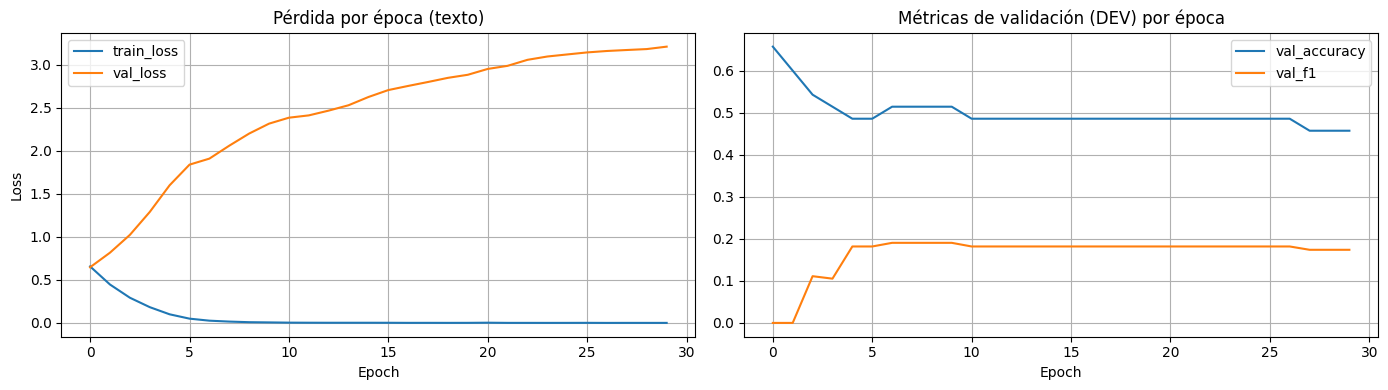

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(history_text["train_loss"], label="train_loss")
ax[0].plot(history_text["val_loss"], label="val_loss")
ax[0].set_title("Pérdida por época (texto)")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history_text["val_acc"], label="val_accuracy")
ax[1].plot(history_text["val_f1"], label="val_f1")
ax[1].set_title("Métricas de validación (DEV) por época")
ax[1].set_xlabel("Epoch")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## 21. Evaluación final del mejor modelo sobre DEV

In [ ]:
text_model.eval()
with torch.no_grad():
    y_pred_dev_text = text_model(X_dev_text_t)
    y_pred_dev_text = (y_pred_dev_text > 0.5).float()

acc_text = accuracy_score(y_dev_text_t, y_pred_dev_text)
f1_text = f1_score(y_dev_text_t, y_pred_dev_text, zero_division=0)
cm_text = confusion_matrix(y_dev_text_t, y_pred_dev_text)

print("Accuracy (DEV):", acc_text)
print("F1 (DEV)      :", f1_text)
print("\nMatriz de confusión (DEV):")
print(cm_text)
print("\nReporte de clasificación (DEV):")
print(classification_report(y_dev_text_t, y_pred_dev_text, zero_division=0))

Accuracy (DEV): 0.5142857142857142
F1 (DEV)      : 0.19047619047619047

Matriz de confusión (DEV):
[[16  7]
 [10  2]]

Reporte de clasificación (DEV):
              precision    recall  f1-score   support

         0.0       0.62      0.70      0.65        23
         1.0       0.22      0.17      0.19        12

    accuracy                           0.51        35
   macro avg       0.42      0.43      0.42        35
weighted avg       0.48      0.51      0.49        35



## 22. Guardar productos de la Semana 3

Todo lo que consumen las Semanas 4 y 5 queda en `BASE_PROYECTO`, con nombres análogos a los de la Semana 2:
- `embeddings.csv`, `texto_dataset.csv` (ya guardados, con columna `split`)
- `X_text.npy` / `y_text.npy`: TRAIN+DEV concatenados (en ese orden) junto con `split_text.npy` para poder filtrar por partición oficial
- `X_train_text.npy` / `y_train_text.npy` y `X_dev_text.npy` / `y_dev_text.npy`: partición oficial ya separada, lista para usar directamente
- `scaler_text.pkl`: el `StandardScaler` ajustado en TRAIN (ya guardado en la sección 15; debe reutilizarse, no reajustarse, en semanas posteriores)
- `text_mlp_best.pth`: pesos del mejor modelo (según F1 en DEV)
- `text_week3_metrics.json`: métricas finales e historial de entrenamiento

In [ ]:
# --- matrices combinadas (orden: TRAIN seguido de DEV) ---
X_text = np.concatenate([X_train_text, X_dev_text], axis=0)
y_text = np.concatenate([y_train_text, y_dev_text], axis=0)
split_text = np.array(["train"] * len(y_train_text) + ["dev"] * len(y_dev_text))

np.save(BASE_PROYECTO / "X_text.npy", X_text)
np.save(BASE_PROYECTO / "y_text.npy", y_text)
np.save(BASE_PROYECTO / "split_text.npy", split_text)

# --- matrices separadas por partición oficial ---
np.save(BASE_PROYECTO / "X_train_text.npy", X_train_text)
np.save(BASE_PROYECTO / "y_train_text.npy", y_train_text)
np.save(BASE_PROYECTO / "X_dev_text.npy", X_dev_text)
np.save(BASE_PROYECTO / "y_dev_text.npy", y_dev_text)

# --- modelo ---
torch.save(text_model.state_dict(), BASE_PROYECTO / "text_mlp_best.pth")

# --- métricas e historial ---
metrics_text = {
    "input_dim": int(input_dim_text),
    "n_epochs": N_EPOCHS_TEXT,
    "best_val_f1": float(best_val_f1_text),
    "final_eval_dev": {
        "accuracy": float(acc_text),
        "f1": float(f1_text),
        "confusion_matrix": cm_text.tolist(),
    },
    "history": history_text,
    "feature_names": feature_cols_text,
}

with open(BASE_PROYECTO / "text_week3_metrics.json", "w", encoding="utf-8") as f:
    _json.dump(metrics_text, f, indent=2, ensure_ascii=False)

print("✓ Todos los productos de la Semana 3 fueron guardados en:", BASE_PROYECTO)

✓ Todos los productos de la Semana 3 fueron guardados en: /content/drive/MyDrive/Colab Notebooks/Programa Delphin


## 23. Verificación de los archivos generados

In [ ]:
# ============================================================
# VERIFICACIÓN DE LOS ARCHIVOS GENERADOS
# ============================================================

embeddings_check = pd.read_csv(BASE_PROYECTO / "embeddings.csv")
texto_dataset_check = pd.read_csv(BASE_PROYECTO / "texto_dataset.csv")
X_text_check = np.load(BASE_PROYECTO / "X_text.npy")
y_text_check = np.load(BASE_PROYECTO / "y_text.npy")
split_text_check = np.load(BASE_PROYECTO / "split_text.npy", allow_pickle=True)

print("="*60)
print("VERIFICACIÓN DE LOS ARCHIVOS GENERADOS")
print("="*60)

print("embeddings.csv     :", embeddings_check.shape)
print("texto_dataset.csv  :", texto_dataset_check.shape)
print("X_text.npy         :", X_text_check.shape)
print("y_text.npy         :", y_text_check.shape)
print("split_text.npy     :", split_text_check.shape)

assert embeddings_check.shape[0] == texto_dataset_check.shape[0], \
    "embeddings.csv y texto_dataset.csv tienen distinto número de filas."
assert X_text_check.shape[0] == len(y_text_check) == len(split_text_check), \
    "X_text, y_text y split_text no tienen el mismo número de filas."

print("\n✓ Todos los archivos existen y tienen dimensiones consistentes entre sí.")

VERIFICACIÓN DE LOS ARCHIVOS GENERADOS
embeddings.csv     : (142, 770)
texto_dataset.csv  : (142, 772)
X_text.npy         : (142, 768)
y_text.npy         : (142,)
split_text.npy     : (142,)

✓ Todos los archivos existen y tienen dimensiones consistentes entre sí.


## 24. Verificación de integridad del dataset

In [ ]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL DATASET
# ============================================================

print("="*60)
print("VERIFICACIÓN DE INTEGRIDAD DEL DATASET")
print("="*60)

print("Participantes únicos:", texto_dataset_check["Participant_ID"].nunique())

print("\nDistribución por split:")
print(texto_dataset_check["split"].value_counts())

print("\nDistribución de PHQ8_Binary por split:")
print(texto_dataset_check.groupby("split")["PHQ8_Binary"].value_counts())

# Verificaciones de consistencia

assert texto_dataset_check["Participant_ID"].is_unique, \
    "Hay participantes duplicados en texto_dataset."

assert X_text_check.shape[0] == len(texto_dataset_check), \
    "X_text y texto_dataset no coinciden en número de filas."

assert X_text_check.shape[1] == 768, \
    "Las dimensiones del embedding no son 768."

assert not np.any(np.isnan(X_text_check)), "X_text contiene valores NaN."
assert not np.any(np.isinf(X_text_check)), "X_text contiene valores Inf."

print("\n✓ No existen participantes duplicados.")
print("✓ X_text y texto_dataset son consistentes en tamaño.")
print("✓ Todos los embeddings tienen 768 dimensiones.")
print("✓ No existen valores NaN ni Inf en X_text.")

VERIFICACIÓN DE INTEGRIDAD DEL DATASET
Participantes únicos: 142

Distribución por split:
split
train    107
dev       35
Name: count, dtype: int64

Distribución de PHQ8_Binary por split:
split  PHQ8_Binary
dev    0              23
       1              12
train  0              77
       1              30
Name: count, dtype: int64

✓ No existen participantes duplicados.
✓ X_text y texto_dataset son consistentes en tamaño.
✓ Todos los embeddings tienen 768 dimensiones.
✓ No existen valores NaN ni Inf en X_text.


## 25. Validación metodológica (TRAIN / DEV / TEST)

In [ ]:
# ============================================================
# VALIDACIÓN METODOLÓGICA DEL DATASET DE TEXTO
# ============================================================

ids_train_final = set(
    texto_dataset_check.loc[texto_dataset_check["split"] == "train", "Participant_ID"]
)
ids_dev_final = set(
    texto_dataset_check.loc[texto_dataset_check["split"] == "dev", "Participant_ID"]
)
ids_test_final = set(test_df["Participant_ID"])
ids_full_test_final = set(full_test_df["Participant_ID"])

assert ids_train_final.isdisjoint(ids_dev_final), \
    "TRAIN y DEV contienen participantes repetidos."
assert (ids_train_final | ids_dev_final).isdisjoint(ids_test_final), \
    "El conjunto TEST fue incluido en el procesamiento de texto."
assert ids_dev_final.isdisjoint(ids_test_final), \
    "DEV y TEST comparten participantes."

# Compatibilidad estricta con la Semana 2 (mismos participantes, mismos splits)
assert ids_train_final == ids_audio_train, \
    "TRAIN de texto no coincide con TRAIN de audio (Semana 2)."
assert ids_dev_final == ids_audio_dev, \
    "DEV de texto no coincide con DEV de audio (Semana 2)."

print("="*60)
print("VALIDACIÓN METODOLÓGICA")
print("="*60)

print(f"Participantes TRAIN : {len(ids_train_final)}")
print(f"Participantes DEV   : {len(ids_dev_final)}")
print(f"Participantes TEST  : {len(ids_test_final)}")

print("\nDistribución TRAIN:")
print(texto_dataset_check.loc[texto_dataset_check["split"] == "train", "PHQ8_Binary"].value_counts())

print("\nDistribución DEV:")
print(texto_dataset_check.loc[texto_dataset_check["split"] == "dev", "PHQ8_Binary"].value_counts())

print("\nParticipantes también presentes en FULL_TEST:",
      len((ids_train_final | ids_dev_final) & ids_full_test_final))

print("\n✓ TRAIN y DEV no se solapan.")
print("✓ TEST oficial no fue utilizado en ninguna etapa (limpieza, tokenización, embeddings, entrenamiento).")
print("✓ No existe data leakage.")
print("✓ Los splits de texto son idénticos a los de audio (Semana 2): integración multimodal segura.")
print("\n" + "="*60)
print("SEMANA 3 FINALIZADA - LISTA PARA LA SEMANA 4")
print("="*60)

VALIDACIÓN METODOLÓGICA
Participantes TRAIN : 107
Participantes DEV   : 35
Participantes TEST  : 47

Distribución TRAIN:
PHQ8_Binary
0    77
1    30
Name: count, dtype: int64

Distribución DEV:
PHQ8_Binary
0    23
1    12
Name: count, dtype: int64

Participantes también presentes en FULL_TEST: 0

✓ TRAIN y DEV no se solapan.
✓ TEST oficial no fue utilizado en ninguna etapa (limpieza, tokenización, embeddings, entrenamiento).
✓ No existe data leakage.
✓ Los splits de texto son idénticos a los de audio (Semana 2): integración multimodal segura.

SEMANA 3 FINALIZADA - LISTA PARA LA SEMANA 4


## 26. Estadísticas del corpus

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2226 > 512). Running this sequence through the model will result in indexing errors


============== PALABRAS ==============
Control Media: 1390.93 Mediana: 1217.0 Máximo: 4112
Depresión Media: 1477.452380952381 Mediana: 1414.5 Máximo: 3933

============== TOKENS ==============
Control Media: 1608.51 Mediana: 1428.0 Máximo: 4553
Depresión Media: 1725.4761904761904 Mediana: 1604.0 Máximo: 4710


/tmp/ipykernel_3049/1845906248.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


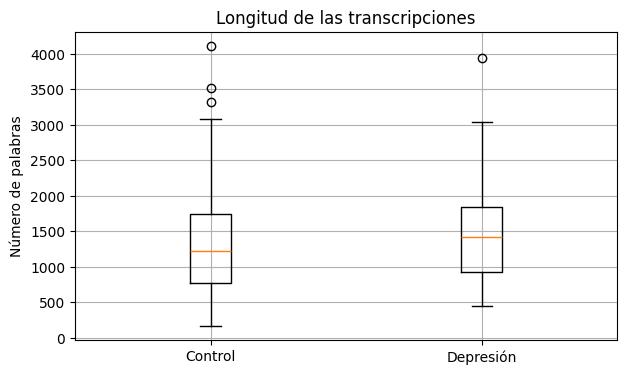

In [41]:
# ============================================================
# 26. Estadísticas del corpus de texto
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

word_counts = {"Control": [], "Depresión": []}
token_counts = {"Control": [], "Depresión": []}

for _, row in texto_dataset_df.iterrows():

    pid = int(row["Participant_ID"])
    texto = clean_text(get_full_text(pid, BASE))

    n_palabras = len(texto.split())

    n_tokens = len(
        tokenizer(
            texto,
            truncation=False
        )["input_ids"]
    )

    if row["PHQ8_Binary"] == 0:
        word_counts["Control"].append(n_palabras)
        token_counts["Control"].append(n_tokens)
    else:
        word_counts["Depresión"].append(n_palabras)
        token_counts["Depresión"].append(n_tokens)

print("============== PALABRAS ==============")

for clase in word_counts:
    print(
        clase,
        "Media:",
        np.mean(word_counts[clase]),
        "Mediana:",
        np.median(word_counts[clase]),
        "Máximo:",
        np.max(word_counts[clase])
    )

print("\n============== TOKENS ==============")

for clase in token_counts:
    print(
        clase,
        "Media:",
        np.mean(token_counts[clase]),
        "Mediana:",
        np.median(token_counts[clase]),
        "Máximo:",
        np.max(token_counts[clase])
    )

plt.figure(figsize=(7,4))
plt.boxplot(
    [word_counts["Control"], word_counts["Depresión"]],
    labels=["Control","Depresión"]
)
plt.ylabel("Número de palabras")
plt.title("Longitud de las transcripciones")
plt.grid(True)
plt.show()

## 27. Comparación Audio vs Texto

,Modelo,Accuracy,F1
0,Audio CNN,0.638300,0.320000
1,Texto BERT,0.514286,0.190476


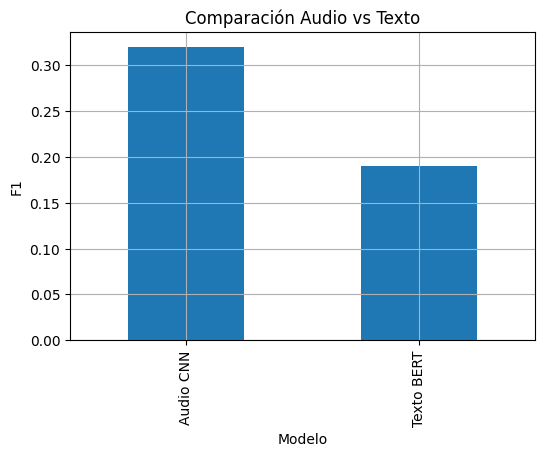

In [42]:
# ============================================================
# 27. Comparación Audio vs Texto
# ============================================================

import pandas as pd

comparacion = pd.DataFrame({

    "Modelo":[
        "Audio CNN",
        "Texto BERT"
    ],

    "Accuracy":[
        0.6383,
        acc_text
    ],

    "F1":[
        0.3200,
        f1_text
    ]

})

display(comparacion)

comparacion.plot(
    x="Modelo",
    y="F1",
    kind="bar",
    legend=False,
    figsize=(6,4),
    title="Comparación Audio vs Texto"
)

plt.ylabel("F1")
plt.grid(True)
plt.show()

## 28. Conclusiones de la Semana 3

In [43]:
# ============================================================
# 28. Conclusiones
# ============================================================

print("="*70)
print("CONCLUSIONES DE LA SEMANA 3")
print("="*70)

print(f"""
• Se procesaron correctamente {len(texto_dataset_df)} participantes.

• Se generaron embeddings de 768 dimensiones usando BERT.

• Se construyó el dataset de texto compatible con la Semana 2.

• Se utilizaron exclusivamente los conjuntos TRAIN y DEV oficiales.

• No existe data leakage.

• Todos los artefactos fueron generados correctamente.

Resultados del clasificador

Accuracy DEV : {acc_text:.4f}

F1 DEV       : {f1_text:.4f}

La información quedó lista para ser utilizada
en la Semana 4 (comparación de modelos)
y la Semana 5 (fusión multimodal).
""")

CONCLUSIONES DE LA SEMANA 3

• Se procesaron correctamente 142 participantes.

• Se generaron embeddings de 768 dimensiones usando BERT.

• Se construyó el dataset de texto compatible con la Semana 2.

• Se utilizaron exclusivamente los conjuntos TRAIN y DEV oficiales.

• No existe data leakage.

• Todos los artefactos fueron generados correctamente.

Resultados del clasificador

Accuracy DEV : 0.5143

F1 DEV       : 0.1905

La información quedó lista para ser utilizada
en la Semana 4 (comparación de modelos)
y la Semana 5 (fusión multimodal).

